# Experiment 1: Synthetic Matrix Factorisation (Baseline)

Compare PALM, iPALM, and FISTA-PALM on a synthetic low-rank matrix.

**Setup**
- Matrix: $A \in \mathbb{R}^{100 \times 80}$, rank $r = 10$
- Sparsity: $25\%$ in $Y$
- Initialisation: random nonnegative
- Iterations: $100$

**Goal**

Compare convergence behaviour and final objective values.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))

# Solvers
from src.solvers.palm import PALM
from src.solvers.ipalm import IPALM
from src.solvers.fista_palm import FISTAPALM

# Utils
from src.utils.problem_factory import make_matrix_factorisation_problem
from src.utils.plotting import plot_histories
from src.utils.io import make_fig_path, save_table

In [2]:
np.random.seed(42)

m, n, r = 100, 80, 10
sparsity = 0.25
max_iter = 100

A = np.random.rand(m, r) @ np.random.rand(n, r).T

problem = make_matrix_factorisation_problem(A, r, sparsity)

X0 = np.abs(np.random.randn(m, r))
Y0 = np.abs(np.random.randn(n, r))

## Run solvers

Run PALM, iPALM, and FISTA-PALM from the same initialisation.

In [3]:
solvers = {
    "PALM": PALM(max_iter=max_iter),
    "iPALM": IPALM(max_iter=max_iter),
    "FISTA-PALM": FISTAPALM(max_iter=max_iter),
}

histories = {}

for name, solver in solvers.items():
    _, _, hist = solver.solve(problem, X0.copy(), Y0.copy())
    histories[name] = hist

## Convergence curves

Objective vs iteration (log scale).

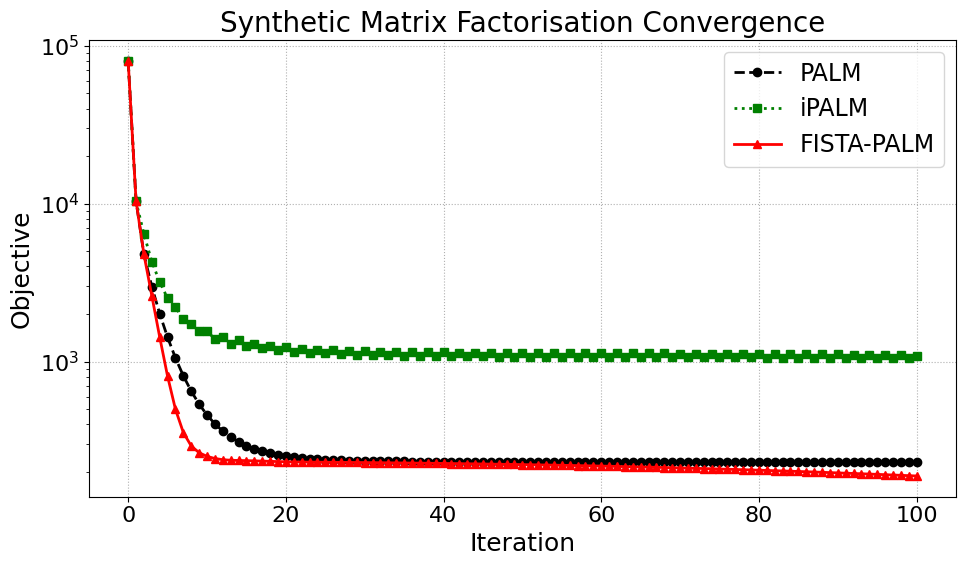

In [4]:
params = {
    "m": m,
    "n": n,
    "r": r,
    "s": sparsity,
    "iter": max_iter,
}

plot_histories(
    histories,
    title="Synthetic Matrix Factorisation Convergence",
    save_path=make_fig_path(ROOT, "baseline_convergence", params),
)

In [5]:
df = pd.DataFrame({
    "Method": ["PALM", "iPALM", "FISTA-PALM"],
    "Final Objective": [
        histories["PALM"][-1],
        histories["iPALM"][-1],
        histories["FISTA-PALM"][-1],
    ],
    "Iterations": [
        len(histories["PALM"]) - 1,
        len(histories["iPALM"]) - 1,
        len(histories["FISTA-PALM"]) - 1,
    ],
})

save_table(
    df,
    ROOT,
    "baseline_summary",
    params,
)

df

,Method,Final Objective,Iterations
0,PALM,230.073099,100
1,iPALM,1091.128403,100
2,FISTA-PALM,188.542537,100


## Observations

- FISTA-PALM decreases the objective fastest in the first few iterations.
- PALM converges more gradually but reaches a similar final objective to FISTA-PALM.
- iPALM reduces the objective initially, but plateaus at a noticeably higher value in this run.
- The acceleration in FISTA-PALM is most visible during the early iterations.